<a href="https://colab.research.google.com/github/KWells58/CAP5610-ML-Project/blob/main/ML_term_project_SZ_contributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#data import & prep

In [ ]:
!pip install datasets transformers scikit-learn torch accelerate -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.utils import shuffle

In [ ]:
from huggingface_hub import login
login()

In [ ]:
dataset = load_dataset("fancyzhx/dbpedia_14")

print(dataset)
print("\nexample entry:")
print(dataset['train'][0])

README.md: 0.00B [00:00, ?B/s]

dbpedia_14/train-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

dbpedia_14/test-00000-of-00001.parquet:   0%|          | 0.00/13.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/70000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['label', 'title', 'content'],
        num_rows: 70000
    })
})

example entry:
{'label': 0, 'title': 'E. D. Abbott Ltd', 'content': ' Abbott of Farnham E D Abbott Limited was a British coachbuilding business based in Farnham Surrey trading under that name from 1929. A major part of their output was under sub-contract to motor vehicle manufacturers. Their business closed in 1972.'}


In [ ]:
label_names = dataset['train'].features['label'].names
print("number of classes:", len(label_names))
print("class labels:", label_names)

print(f"\ntraining split: {len(dataset['train'])}")
print(f"\ntesting split: {len(dataset['test'])}")

number of classes: 14
class labels: ['Company', 'EducationalInstitution', 'Artist', 'Athlete', 'OfficeHolder', 'MeanOfTransportation', 'Building', 'NaturalPlace', 'Village', 'Animal', 'Plant', 'Album', 'Film', 'WrittenWork']

training split: 560000

testing split: 70000


In [ ]:
#kernal svm

In [ ]:
from sklearn.utils import shuffle

def sample_dataset(hf_dataset, samples_per_class=500, seed=42):
    """Sample a fixed number of examples per class for balance."""
    df = pd.DataFrame(hf_dataset)
    sampled = df.groupby('label', group_keys=False).apply(
        lambda x: x.sample(min(samples_per_class, len(x)), random_state=seed)
    )
    return shuffle(sampled, random_state=seed).reset_index(drop=True)

train_df = sample_dataset(dataset['train'], samples_per_class=5000)
test_df  = sample_dataset(dataset['test'],  samples_per_class=200)

print(f"sampled train size: {len(train_df)}")
print(f"sampled test size: {len(test_df)}")
print("\nclass distribution in train set:")
print(train_df['label'].value_counts().sort_index())

/tmp/ipykernel_4153/2464061779.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = df.groupby('label', group_keys=False).apply(


sampled train size: 70000
sampled test size: 2800

class distribution in train set:
label
0     5000
1     5000
2     5000
3     5000
4     5000
5     5000
6     5000
7     5000
8     5000
9     5000
10    5000
11    5000
12    5000
13    5000
Name: count, dtype: int64


/tmp/ipykernel_4153/2464061779.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = df.groupby('label', group_keys=False).apply(


In [ ]:
train_df['text'] = train_df['title'] + " " + train_df['content']
test_df['text']  = test_df['title']  + " " + test_df['content']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidfVectorizer = TfidfVectorizer(max_features=50000, sublinear_tf=True)

X_train = tfidfVectorizer.fit_transform(train_df['text'])
X_test  = tfidfVectorizer.transform(test_df['text'])

y_train = train_df['label'].values
y_test  = test_df['label'].values

print("train shape:", X_train.shape)
print("test shape: ", X_test.shape)

train shape: (70000, 50000)
test shape:  (2800, 50000)


In [ ]:
from sklearn.svm import SVC

svmModel = SVC(kernel='rbf', C=1.0, gamma='scale')
svmModel.fit(X_train, y_train)

print("training complete")

training complete


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

y_pred = svmModel.predict(X_test)

svmAccuracy = accuracy_score(y_test, y_pred)
svmMacroF1  = f1_score(y_test, y_pred, average='macro')

print("accuracy: ", round(svmAccuracy, 4))
print("f1: ", round(svmMacroF1, 4))

accuracy:  0.9789
f1:  0.979


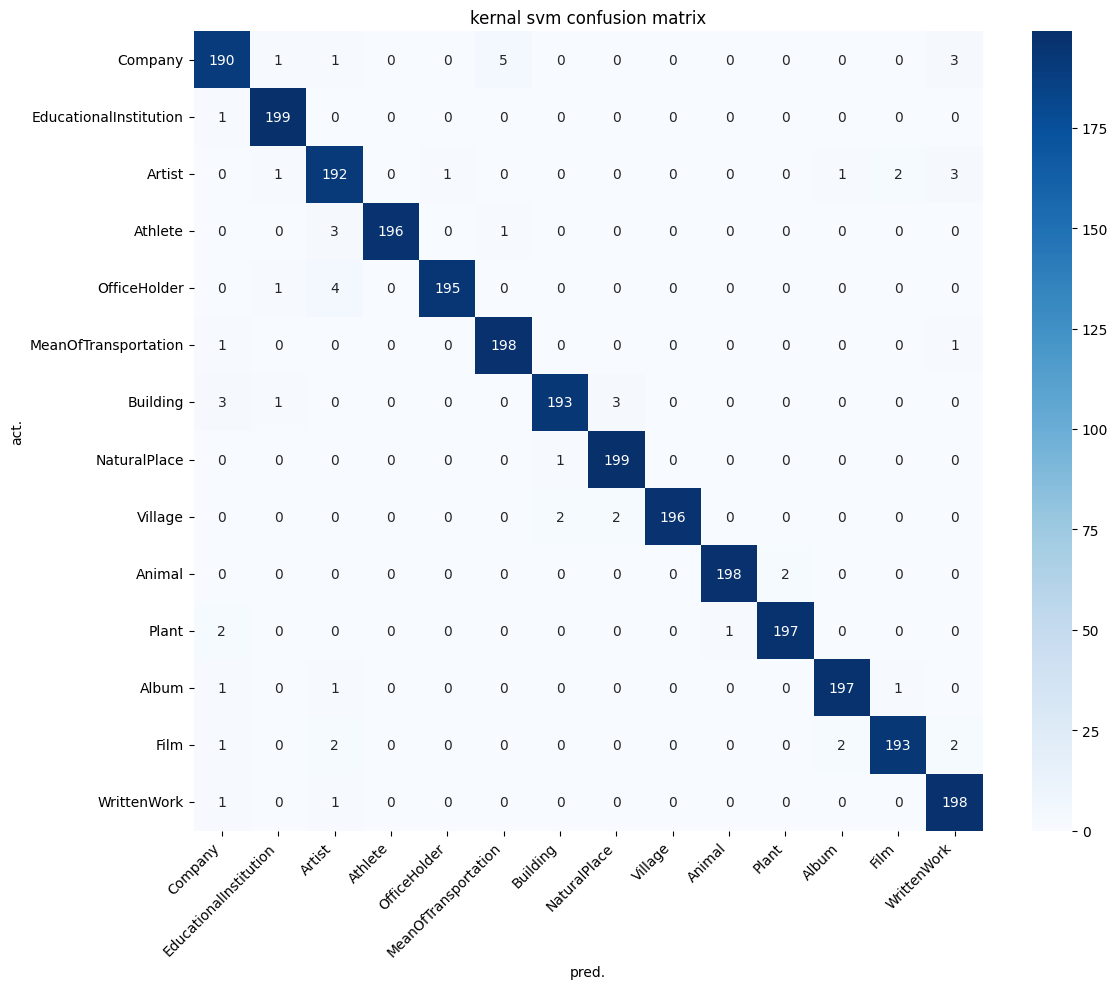

In [ ]:
cmSVM = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cmSVM, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title("kernal svm confusion matrix")
plt.xlabel("pred.")
plt.ylabel("act.")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=label_names))

                        precision    recall  f1-score   support

               Company       0.95      0.95      0.95       200
EducationalInstitution       0.98      0.99      0.99       200
                Artist       0.94      0.96      0.95       200
               Athlete       1.00      0.98      0.99       200
          OfficeHolder       0.99      0.97      0.98       200
  MeanOfTransportation       0.97      0.99      0.98       200
              Building       0.98      0.96      0.97       200
          NaturalPlace       0.98      0.99      0.99       200
               Village       1.00      0.98      0.99       200
                Animal       0.99      0.99      0.99       200
                 Plant       0.99      0.98      0.99       200
                 Album       0.98      0.98      0.98       200
                  Film       0.98      0.96      0.97       200
           WrittenWork       0.96      0.99      0.97       200

              accuracy                

In [ ]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

if(torch.cuda.memory_allocated() == 0):
  print("mem clear")
else:
  print("mem not clear")

mem clear


In [ ]:
#decoder only llm

In [ ]:
from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
def tokenizeData(df, tokenizer, maxLength=128):
    return tokenizer(
        df['text'].tolist(),
        truncation=True,
        padding='max_length',
        max_length=maxLength,
        return_tensors='pt'
    )

trainEncodings = tokenizeData(train_df, tokenizer)
testEncodings  = tokenizeData(test_df, tokenizer)

In [ ]:
print("input ids shape:", trainEncodings['input_ids'].shape)

input ids shape: torch.Size([7000, 128])


In [ ]:
import torch
from torch.utils.data import Dataset

class DBpediaDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

trainDataset = DBpediaDataset(trainEncodings, y_train)
testDataset  = DBpediaDataset(testEncodings, y_test)

In [ ]:
from transformers import GPT2ForSequenceClassification

gptModel = GPT2ForSequenceClassification.from_pretrained(
    "distilgpt2",
    num_labels=14
)
gptModel.config.pad_token_id = tokenizer.eos_token_id

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: distilgpt2
Key                                        | Status     | 
-------------------------------------------+------------+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED | 
score.weight                               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

trainingArgs = TrainingArguments(
    output_dir='./gpt_results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='no',
    logging_steps=50,
    fp16=True,
    report_to='none'
)

In [ ]:
from transformers import Trainer
from sklearn.metrics import accuracy_score, f1_score

def computeMetrics(evalPred):
    logits, labels = evalPred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro')
    }

trainer = Trainer(
    model=gptModel,
    args=trainingArgs,
    train_dataset=trainDataset,
    eval_dataset=testDataset,
    compute_metrics=computeMetrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.082582,0.101933,0.976071,0.976073
2,0.077318,0.091004,0.979286,0.979308
3,0.011383,0.085380,0.984286,0.984278


TrainOutput(global_step=1314, training_loss=0.18239985127427263, metrics={'train_runtime': 18.4963, 'train_samples_per_second': 1135.365, 'train_steps_per_second': 71.041, 'total_flos': 686077378560000.0, 'train_loss': 0.18239985127427263, 'epoch': 3.0})

In [ ]:
gptPreds  = trainer.predict(testDataset)
gptLabels = gptPreds.label_ids
gptPredLabels = np.argmax(gptPreds.predictions, axis=-1)

gptAccuracy = accuracy_score(gptLabels, gptPredLabels)
gptMacroF1  = f1_score(gptLabels, gptPredLabels, average='macro')

print("accuracy:", round(gptAccuracy, 4))
print("f1:", round(gptMacroF1, 4))

accuracy: 0.9843
f1: 0.9843


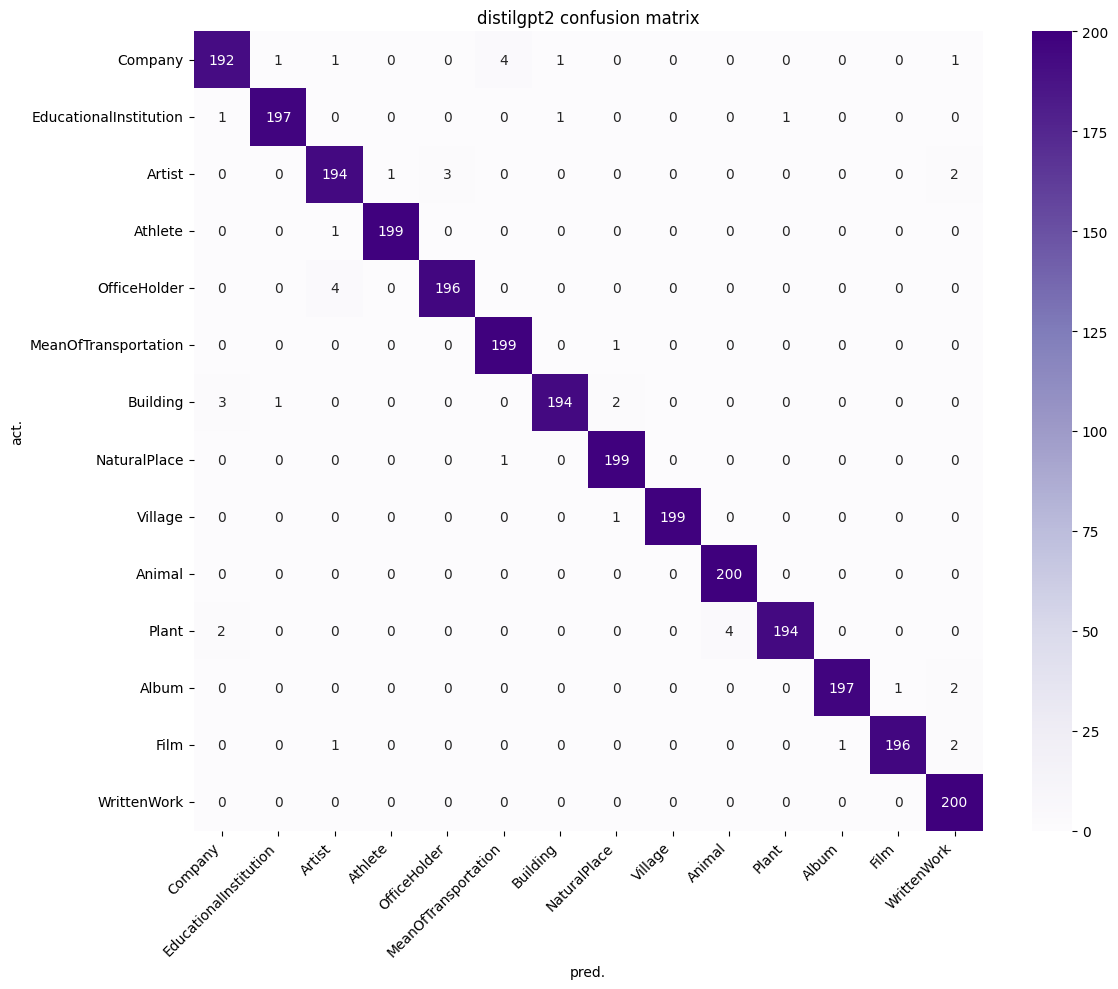

In [ ]:
labelNames = dataset['train'].features['label'].names

cmGPT = confusion_matrix(gptLabels, gptPredLabels)

plt.figure(figsize=(12, 10))
sns.heatmap(cmGPT, annot=True, fmt='d', cmap='Purples',
            xticklabels=labelNames,
            yticklabels=labelNames)
plt.title("distilgpt2 confusion matrix")
plt.xlabel("pred.")
plt.ylabel("act.")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()